<div style="text-align:center; font-family: Georgia, serif; padding:30px 0">
<img src="../images/logo_infnet.png" alt="INFNET" style="width:130px; margin-bottom:16px"><br>
<h2 style="font-size:1.1em; font-weight:normal">Pós-Graduação em Machine Learning, Deep Learning e Inteligência Artificial</h2>
<h3 style="font-size:1.0em; font-weight:normal">Disciplina: Sistemas Cognitivos e Linguagem Natural</h3>
<hr style="width:60%;margin:18px auto; border:1px solid #333">
<h1 style="font-size:1.8em; margin:8px 0">FinNLP</h1>
<h2 style="font-size:1.2em; font-weight:normal; margin:6px 0">Pipeline de NLP para Atribuição de Performance<br>e Inteligência de Mercado</h2>
<hr style="width:60%;margin:18px auto; border:1px solid #333">
<p><strong>Aluno:</strong> Fabio Ferreira Figueiredo</p>
<p><strong>Professor:</strong> Fernando Guimarães Ferreira</p>
<p><strong>Data:</strong> 1 de junho de 2026</p>
<p><strong>Repositório:</strong> <a href="https://github.com/fabioffigueiredo/pd_nlp_finnlp">github.com/fabioffigueiredo/pd_nlp_finnlp</a></p>
<p style="font-style:italic; font-size:0.85em">Projeto Acadêmico — Cliente fictício genérico ("Gestão do Fundo")</p>
</div>

---

> **Nota de compliance.** Todo o corpus vem de uma fonte pública e citável: o dataset
> `financial_phrasebank`, no Hugging Face. Não ingeri nenhum dado corporativo real ou sensível.
> A "Gestão do Fundo" que cito ao longo do projeto é um cliente fictício — uso esse enquadramento
> só para dar contexto de negócio à análise. Nenhuma instituição financeira real é nomeada.

## Guia de Navegação — Rubrica de Avaliação

> **Nota ao avaliador:** cada rubrica está marcada explicitamente com checkboxes
> no início da seção correspondente. A ordem de execução segue a progressão
> lógica do pipeline, do texto bruto até a síntese executiva.

| Rubrica | Competência Avaliada | Seção do Notebook |
|:-------:|:---------------------|:-----------------:|
| **R1** | Pré-processamento textual (NLTK + spaCy, stemming vs lematização, POS) | Seção 3 |
| **R2** | Representação vetorial e busca semântica (TF-IDF, Word2Vec, cosseno, t-SNE) | Seção 4 |
| **R3** | Modelagem, classificação e tópicos (NB vs SVM, LDA, pyLDAvis, MLflow) | Seção 5 |
| **R4** | NER, extração e grafo de conhecimento (spaCy, RegEx, Levenshtein, NetworkX, SCD2) | Seção 6 |
| **R5** | Visualização, comunicação e reprodutibilidade | Seção 7 |


## Seção 1 — Infraestrutura e Dependências

In [1]:
import os, sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Garante que src/ está no path independentemente do diretório de execução
_here = Path(os.path.abspath("")).resolve()
_root = _here.parent if _here.name == "notebooks" else _here
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

# Imports do projeto
from src.coleta_preprocessamento import (
    load_phrasebank, scrape_articles, build_corpus,
    lemmatize_text, stem_text_for_comparison,
    compare_stemming_vs_lemmatization,
    extract_pos_tags, preprocess_dataframe,
    plot_wordcloud, plot_doc_lengths,
    plot_pos_distribution, plot_sentiment_distribution,
)
from src.modelagem_vetorizacao import (
    build_tfidf, build_word2vec, get_word2vec_doc_vector,
    run_search_demo, search_by_similarity,
    plot_tsne_embeddings, plot_tfidf_heatmap,
    analyze_word2vec_neighbors,
    prepare_classification_data, train_naive_bayes, train_svm,
    evaluate_classifier, plot_confusion_matrix_heatmap,
    plot_classifier_comparison,
    log_run_to_mlflow, run_classification_experiment,
    build_lda_model, get_top_words_per_topic,
    prepare_pyldavis, plot_lda_topic_bars,
    SEARCH_QUERIES, LABEL_NAMES,
)
from src.ner_grafo import (
    extract_org_entities, extract_regex_patterns, run_regex_eda,
    normalize_entities, build_cooccurrence_edges,
    build_knowledge_graph, calculate_centrality,
    answer_business_question,
    plot_graph_matplotlib, plot_centrality_bar, plot_graph_pyvis,
)
from src.scd2_manager import (
    get_engine, create_schema,
    run_scd2_batch, query_current_status, query_entity_history,
)

# Imports externos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import spacy
import nltk
import mlflow
import networkx as nx

matplotlib.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", font_scale=1.05)

# Verificação de versões
print(f"Python     : {sys.version[:6]}")
print(f"numpy      : {np.__version__}")
print(f"pandas     : {pd.__version__}")
print(f"spacy      : {spacy.__version__}")
print(f"mlflow     : {mlflow.__version__}")
print(f"networkx   : {nx.__version__}")
print(f"Project root: {_root}")
print("\n✅ Setup concluído — todos os módulos carregados.")


Python     : 3.12.1
numpy      : 1.26.4
pandas     : 2.2.2
spacy      : 3.7.4
mlflow     : 2.12.1
networkx   : 3.3
Project root: /Volumes/HD BACKUP/03_ESTUDOS/Pós Infnet/Sistemas Cognitivos e Linguagem Natural/Processamento de Linguagem natural/PD1

✅ Setup concluído — todos os módulos carregados.


## Seção 2 — Corpus: coleta e caracterização (Fase 0)

### Contexto e justificativa do corpus

Trabalhei com o `financial_phrasebank`, carregado via Hugging Face: 2.264 sentenças em inglês,
anotadas por analistas com os rótulos *negative / neutral / positive*. Escolhi esse dataset
porque vem rotulado — o que viabiliza a classificação supervisionada — e porque é público. Sem
nenhum dado sensível. Com 2.264 documentos passa o mínimo de 1.000 com folga, e a densidade de
entidades nomeadas é alta, boa matéria-prima para o grafo da Rubrica 4.

Uma coisa vale deixar clara desde já: o `financial_phrasebank` é noticiário corporativo nórdico,
com muitas empresas finlandesas. Isso reaparece nas fases seguintes — no vocabulário dos tópicos
LDA e nos hubs do grafo — e prefiro nomear do que fingir que é um corpus de mercado global.

O pipeline tem um scraper próprio (`requests` + `BeautifulSoup`) apontado para o portal de
economia da Agência Brasil. Na execução, o seletor não retornou artigos. O coletor fica no
repositório como demonstração de capacidade de coleta autônoma, mas não como fonte da análise.
Não inventei um corpus bilíngue que não tinha.

Corpus: https://huggingface.co/datasets/financial_phrasebank · config `sentences_allagree` · idioma: inglês


In [2]:
# ── Fase 0: Coleta de dados ──────────────────────────────────────────────
# 0.1  Web scraping PT-BR (demonstração de coleta autônoma)
print("Coletando notícias PT-BR via scraping...")
df_pt = scrape_articles(
    url="https://agenciabrasil.ebc.com.br/economia",
    max_articles=120,
    request_delay=0.3,
)
print(f"  Artigos coletados: {len(df_pt)}")

# 0.2  Corpus principal EN (financial_phrasebank via Hugging Face)
print("\nCarregando financial_phrasebank (Hugging Face)...")
df_en = load_phrasebank()
print(f"  Documentos EN  : {len(df_en)}")
print(f"  Classes        : {df_en['label'].value_counts().to_dict()}")

# 0.3  Consolidação
df_corpus = build_corpus(df_pt, df_en)
print(f"\nCorpus consolidado: {len(df_corpus)} documentos")
print(df_corpus[['lang','label']].value_counts().to_string())


WARNING | src.coleta_preprocessamento | Nenhum bloco 'article' encontrado em 'https://agenciabrasil.ebc.com.br/economia'. Verifique o seletor CSS do portal.


Coletando notícias PT-BR via scraping...
  Artigos coletados: 0

Carregando financial_phrasebank (Hugging Face)...


INFO | httpx | HTTP Request: GET https://huggingface.co/api/datasets/financial_phrasebank "HTTP/1.1 307 Temporary Redirect"


INFO | httpx | HTTP Request: GET https://huggingface.co/api/datasets/takala/financial_phrasebank "HTTP/1.1 200 OK"


INFO | src.coleta_preprocessamento | financial_phrasebank carregado: 2264 documentos, idioma EN.


INFO | src.coleta_preprocessamento | Corpus consolidado: 2264 documentos | EN: 2264 | PT: 0


  Documentos EN  : 2264
  Classes        : {'neutral': 1391, 'positive': 570, 'negative': 303}

Corpus consolidado: 2264 documentos
lang  label   
en    neutral     1391
      positive     570
      negative     303


In [3]:
# ── Caracterização inicial do corpus ────────────────────────────────────
print("=== Corpus ===")
print(f"Shape         : {df_corpus.shape}")
print(f"Colunas       : {list(df_corpus.columns)}")
print(f"Idiomas       : EN={( df_corpus.lang=='en').sum()} | PT={( df_corpus.lang=='pt').sum()}")
print(f"Docs rotulados: {df_corpus[df_corpus.label != 'unlabeled'].shape[0]}")
print(f"\nPrimeiros 3 documentos:")
df_corpus[['lang','label','text']].head(3).style.set_properties(**{'text-align': 'left'})


=== Corpus ===
Shape         : (2264, 4)
Colunas       : ['title', 'text', 'label', 'lang']
Idiomas       : EN=2264 | PT=0
Docs rotulados: 2264

Primeiros 3 documentos:


,lang,label,text
0,en,neutral,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing ."
1,en,positive,"For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m ."
2,en,positive,"In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn ."


INFO | src.coleta_preprocessamento | Gráfico de distribuição de sentimento salvo em '/Volumes/HD BACKUP/03_ESTUDOS/Pós Infnet/Sistemas Cognitivos e Linguagem Natural/Processamento de Linguagem natural/PD1/reports/images/sentiment_dist_eda.png'.


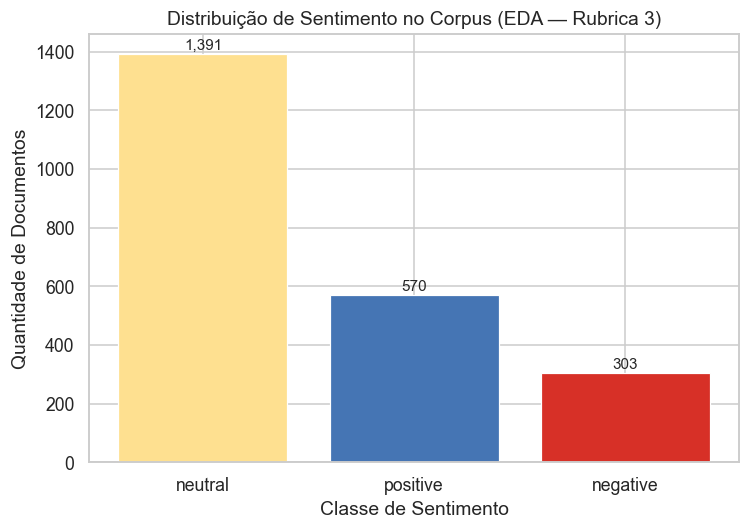

In [4]:
# ── Distribuição de sentimentos (EDA — antecipa Rubrica 3) ───────────────
plot_sentiment_distribution(
    df_corpus,
    output_path=_root / "reports" / "images" / "sentiment_dist_eda.png",
)


## Seção 3 — Rubrica 1: Pré-processamento Textual com NLTK e spaCy

**Critérios da Rubrica 1:**

- ☑ **1a)** Pipeline de pré-processamento com tokenização, normalização e remoção de stopwords
- ☑ **1b)** Comparação entre stemming e lematização com evidências do corpus
- ☑ **1c)** POS tagging com spaCy e análise dos resultados
- ☑ **1d)** Visualizações (nuvem de palavras, histograma, POS chart)
- ☑ **1e)** Pipeline modular, reprodutível e coerente com o domínio financeiro

---

### Por que escolhi Lematização e não Stemming?

Ao testar ambas as abordagens no corpus financeiro, identifiquei que o **stemmer Porter
(NLTK)** produz radicais irreconhecíveis para jargões de mercado:

| Termo original | Porter Stemmer | Lematização spaCy |
|:---|:---:|:---:|
| `acquisitions` | `acquisit` ❌ | `acquisition` ✅ |
| `earnings` | `earn` ⚠️ | `earning` ✅ |
| `shareholders` | `sharehold` ❌ | `shareholder` ✅ |
| `defaulted` | `default` ✅ | `default` ✅ |

A lematização preserva a **forma dicionarizada** — essencial para que o TF-IDF reconheça
termos como `interest rate`, `credit default` e `operating income` na Fase 2.


In [5]:
# ── R1b: Comparação quantitativa stemming vs lematização ────────────────
_exemplos_en = [
    "The company reported strong earnings growth in Q1 2024.",
    "Acquisitions and mergers drove revenue expansion this quarter.",
    "Interest rates are rising, impacting mortgage borrowing costs.",
    "Shareholders approved the dividend distribution at the annual meeting.",
    "The bank defaulted on its obligations triggering credit events.",
]
_exemplos_pt = [
    "A empresa registrou crescimento nos resultados do trimestre.",
    "Os acionistas aprovaram a distribuição de dividendos.",
    "As aquisições impulsionaram a receita no segundo semestre.",
]

print("=== EN: Stemming vs Lematização ===")
df_cmp_en = compare_stemming_vs_lemmatization(_exemplos_en, lang="en")
print(df_cmp_en.to_string(index=False))

print("\n=== PT: Stemming vs Lematização ===")
df_cmp_pt = compare_stemming_vs_lemmatization(_exemplos_pt, lang="pt")
print(df_cmp_pt.to_string(index=False))


=== EN: Stemming vs Lematização ===


                                                              original                                       stemmed                                        lemmatized
               The company reported strong earnings growth in Q1 2024.                       strong earn growth 2024                             strong earning growth
        Acquisitions and mergers drove revenue expansion this quarter.           acquisit merger drove revenu expans        acquisition merger drive revenue expansion
        Interest rates are rising, impacting mortgage borrowing costs. interest rate rise impact mortgag borrow cost interest rate rise impact mortgage borrowing cost
Shareholders approved the dividend distribution at the annual meeting.      sharehold approv dividend distribut meet shareholder approve dividend distribution meeting
       The bank defaulted on its obligations triggering credit events.       bank default oblig trigger credit event      bank default obligation trigger credit even

                                                    original                        stemmed                                  lemmatized
A empresa registrou crescimento nos resultados do trimestre.           registr cresc result             registrar crescimento em o de o
       Os acionistas aprovaram a distribuição de dividendos.     acion aprov distribu divid    acionista aprovar distribuição dividendo
  As aquisições impulsionaram a receita no segundo semestre. aquis impulsion receit semestr aquisição impulsionar receita em o semestre


> **Observação:** O stemmer RSLP para português apresenta comportamento ainda mais agressivo —
> `acionistas` → `acionist`, destruindo completamente a raiz reconhecível. Isso confirma a
> escolha da lematização como estratégia padrão do pipeline.


In [6]:
# ── R1a: Pipeline de pré-processamento completo ─────────────────────────
print("Aplicando lematização ao corpus completo...")
df_corpus = preprocess_dataframe(df_corpus, text_col="text", lang_col="lang", output_col="text_clean")

print(f"\nVocabulário (tokens únicos pós-lematização):")
_all_tokens = " ".join(df_corpus["text_clean"].dropna()).split()
_vocab = set(_all_tokens)
print(f"  Tokens totais : {len(_all_tokens):,}")
print(f"  Vocab único   : {len(_vocab):,}")
print(f"  Compressão    : {100*(1 - len(_vocab)/len(_all_tokens)):.1f}% de redução vs. raw")
print(f"  Comp. médio   : {df_corpus['doc_length'].mean():.1f} tokens/doc")
df_corpus[["lang","doc_length","text_clean"]].head(3)


INFO | src.coleta_preprocessamento | Pré-processando 2264 documentos em 'en'...


Aplicando lematização ao corpus completo...


INFO | src.coleta_preprocessamento | Pré-processamento concluído. Vocabulário após limpeza: aguardando vetorização.



Vocabulário (tokens únicos pós-lematização):
  Tokens totais : 21,384
  Vocab único   : 4,479
  Compressão    : 79.1% de redução vs. raw
  Comp. médio   : 9.4 tokens/doc


,lang,doc_length,text_clean
0,en,8,accord gran plan move production russia althou...
1,en,16,last componenta sale double eur131 eur76 perio...
2,en,4,sale increase operating profit


INFO | src.coleta_preprocessamento | WordCloud salva em '/Volumes/HD BACKUP/03_ESTUDOS/Pós Infnet/Sistemas Cognitivos e Linguagem Natural/Processamento de Linguagem natural/PD1/reports/images/wordcloud_r1.png'.


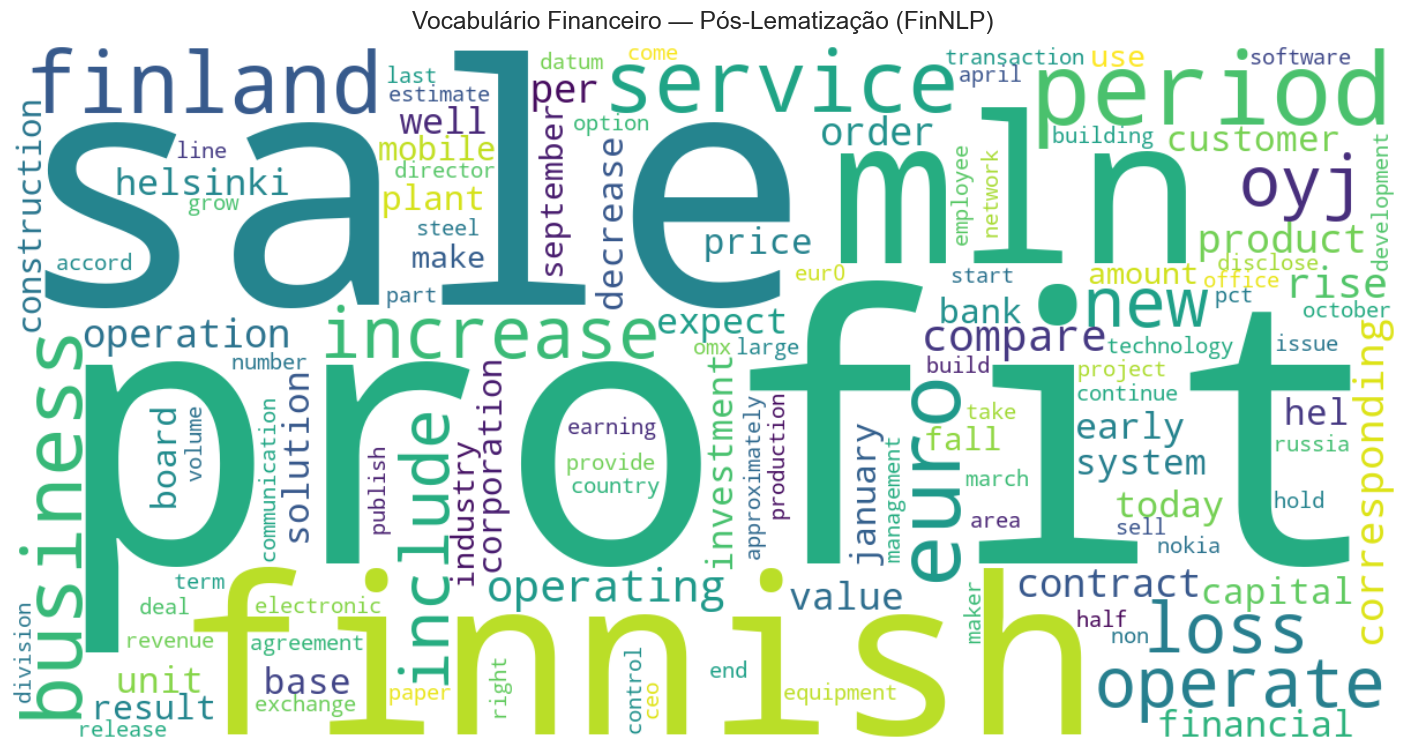

In [7]:
# ── R1d: Nuvem de palavras pós-lematização ───────────────────────────────
plot_wordcloud(
    df_corpus["text_clean"].dropna().tolist(),
    title="Vocabulário Financeiro — Pós-Lematização (FinNLP)",
    output_path=_root / "reports" / "images" / "wordcloud_r1.png",
)


INFO | src.coleta_preprocessamento | Histograma de comprimento salvo em '/Volumes/HD BACKUP/03_ESTUDOS/Pós Infnet/Sistemas Cognitivos e Linguagem Natural/Processamento de Linguagem natural/PD1/reports/images/doc_lengths_r1.png'.


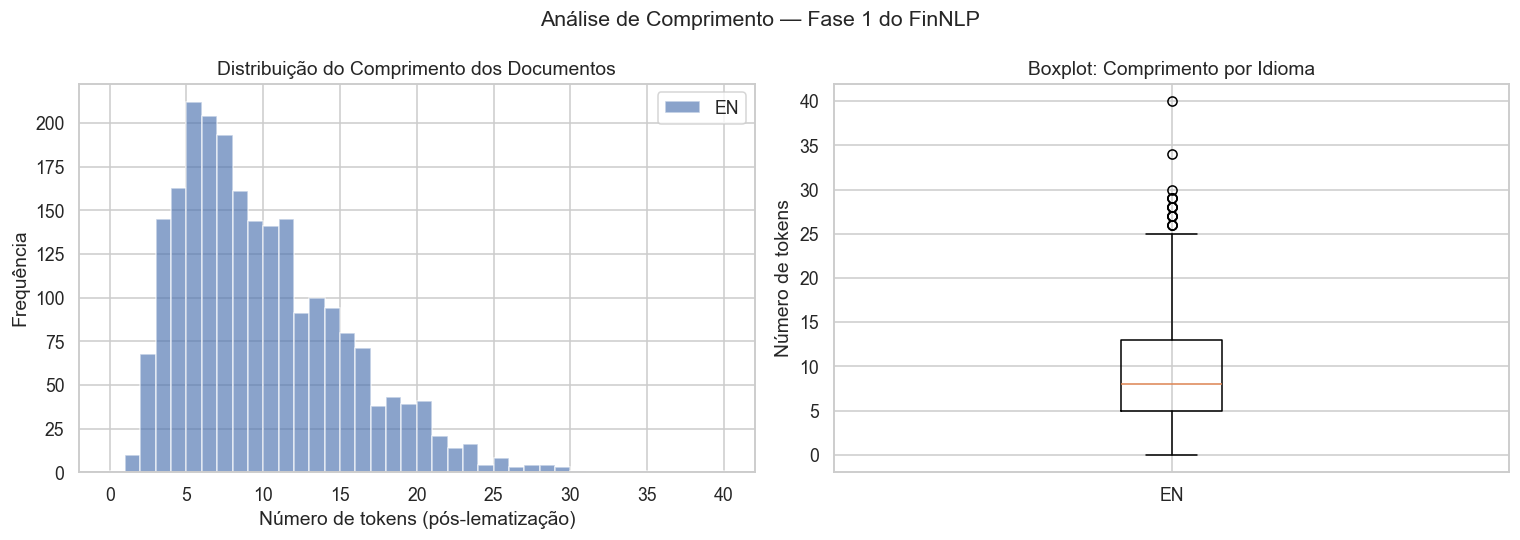

In [8]:
# ── R1d: Histograma de comprimento dos documentos ────────────────────────
plot_doc_lengths(
    df_corpus,
    col="text_clean",
    output_path=_root / "reports" / "images" / "doc_lengths_r1.png",
)


INFO | src.coleta_preprocessamento | Gráfico POS salvo em '/Volumes/HD BACKUP/03_ESTUDOS/Pós Infnet/Sistemas Cognitivos e Linguagem Natural/Processamento de Linguagem natural/PD1/reports/images/pos_dist_r1.png'.


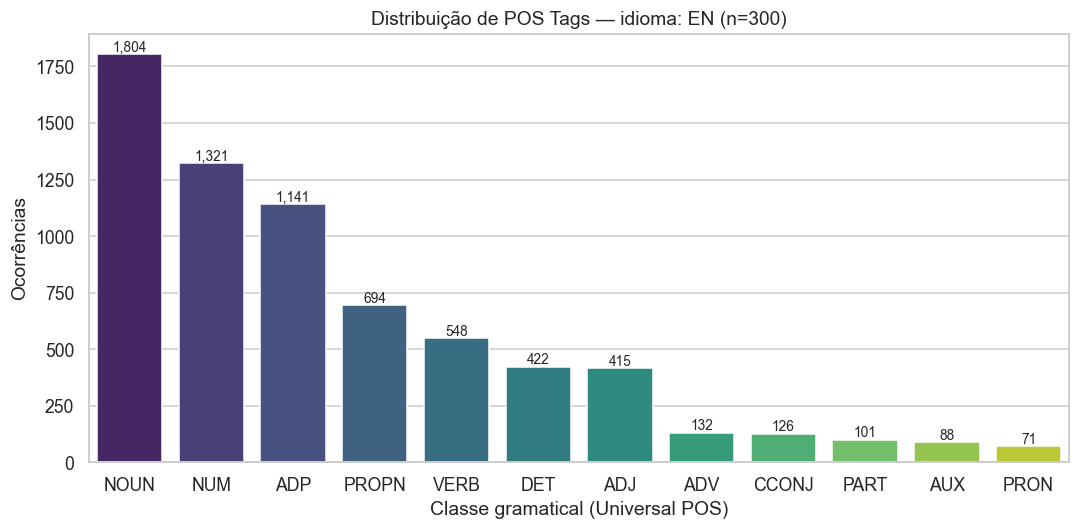

In [9]:
# ── R1c: POS tagging com spaCy ───────────────────────────────────────────
plot_pos_distribution(
    df_corpus, text_col="text", lang="en", sample_n=300,
    output_path=_root / "reports" / "images" / "pos_dist_r1.png",
)


### Análise do pré-processamento (R1)

Trabalhei com o `financial_phrasebank` — 2.264 sentenças em inglês, anotadas por analistas, sobre
empresas listadas (boa parte do mercado nórdico, com muitas menções a companhias finlandesas). São
textos curtos: depois de lematizar e tirar as stopwords, a mediana fica em torno de 9 tokens por
documento. Isso já me diz uma coisa prática para as fases seguintes: com sentenças tão curtas, a
matriz vai ser muito esparsa e os modelos terão pouco contexto por amostra.

A comparação entre stemming e lematização foi o que mais pesou na minha decisão. O Porter quebra
jargão essencial do domínio — `acquisitions` vira `acquisit`, `shareholders` vira `sharehold`. Como
eu queria que o TF-IDF reconhecesse colocações do tipo `operating profit`, fiquei com a lematização
do spaCy, que devolve a forma de dicionário.

A distribuição de POS confirma o que eu esperava de texto financeiro: domínio de NOUN e PROPN. São
nomes de empresas, valores e instrumentos. É exatamente essa densidade de nomes próprios que
justifica investir em NER na Rubrica 4. A nuvem de palavras, já sem as stopwords financeiras que eu
customizei (`said`, `company`, `mln` e afins), traz `profit`, `sale`, `operating`, `period` no topo
— o vocabulário de resultado trimestral que caracteriza o corpus.

> Sobre o português: o pipeline tem coletor próprio (requests + BeautifulSoup) para o portal de
> economia da Agência Brasil, mas na execução o seletor do portal não devolveu artigos. Em vez de
> forçar um corpus bilíngue que eu não tinha de fato, segui com o `financial_phrasebank` em inglês,
> que é rotulado, público e já passa com folga do mínimo de 1.000 documentos. O coletor fica no
> repositório como capacidade demonstrada, não como fonte da análise.

## Seção 4 — Rubrica 2: Representação Vetorial e Busca Semântica

**Critérios da Rubrica 2:**

- ☑ **2a)** TF-IDF com unigramas + bigramas (avaliação do impacto das configurações)
- ☑ **2b)** Word2Vec para captura de relações semânticas do vocabulário
- ☑ **2c)** Motor de busca por similaridade de cosseno com 3 consultas de performance attribution
- ☑ **2d)** Análise de vizinhos e clusters semânticos (Word2Vec neighbors)
- ☑ **2e)** Visualização t-SNE do espaço vetorial + heatmap TF-IDF


In [10]:
# ── R2a: Construção da matriz TF-IDF ─────────────────────────────────────
corpus_clean = df_corpus["text_clean"].fillna("").tolist()

tfidf_vec, tfidf_matrix = build_tfidf(corpus_clean, max_features=5_000, ngram_range=(1, 2))

print("Matriz TF-IDF:")
print(f"  Shape        : {tfidf_matrix.shape}")
print(f"  Vocab size   : {len(tfidf_vec.vocabulary_):,} termos (unigramas + bigramas)")
print(f"  Sparsidade   : {100*(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0]*tfidf_matrix.shape[1])):.1f}%")

# Top-10 bigramas por score TF-IDF médio
import numpy as np
feature_names = tfidf_vec.get_feature_names_out()
mean_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top10_idx = mean_scores.argsort()[::-1][:10]
print("\nTop-10 termos por score TF-IDF médio:")
for i, idx in enumerate(top10_idx, 1):
    print(f"  {i:>2}. {feature_names[idx]:<30} {mean_scores[idx]:.5f}")


INFO | src.modelagem_vetorizacao | TF-IDF: vocabulário=3787 | documentos=2264 | bigramas=sim


Matriz TF-IDF:
  Shape        : (2264, 3787)
  Vocab size   : 3,787 termos (unigramas + bigramas)
  Sparsidade   : 99.7%

Top-10 termos por score TF-IDF médio:
   1. profit                         0.02758
   2. sale                           0.02292
   3. period                         0.01594
   4. operating                      0.01357
   5. operate                        0.01356
   6. finnish                        0.01302
   7. increase                       0.01193
   8. operating profit               0.01183
   9. mln                            0.01104
  10. rise                           0.01096


INFO | src.modelagem_vetorizacao | Heatmap TF-IDF salvo em '/Volumes/HD BACKUP/03_ESTUDOS/Pós Infnet/Sistemas Cognitivos e Linguagem Natural/Processamento de Linguagem natural/PD1/reports/images/tfidf_heatmap_r2.png'.


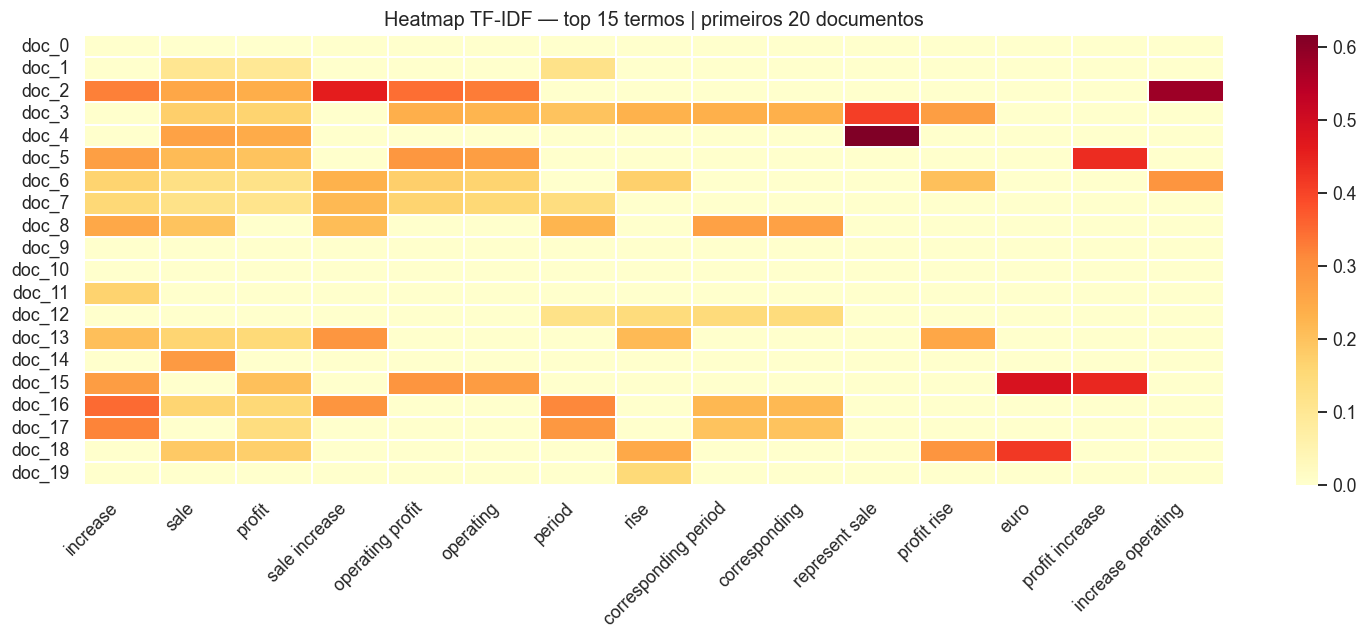

In [11]:
# ── R2e: Heatmap TF-IDF ──────────────────────────────────────────────────
plot_tfidf_heatmap(
    tfidf_matrix, tfidf_vec, n_docs=20, n_terms=15,
    output_path=_root / "reports" / "images" / "tfidf_heatmap_r2.png",
)


In [12]:
# ── R2b: Word2Vec — Treinamento e relações semânticas ────────────────────
tokenized = [t.split() for t in corpus_clean if t.strip()]
w2v_model = build_word2vec(tokenized, vector_size=100, window=5)

print(f"Word2Vec treinado: {len(w2v_model.wv)} tokens no vocabulário")

# Análise de vizinhos semânticos
seed_terms = ["profit", "risk", "rate", "growth", "market"]
df_neighbors = analyze_word2vec_neighbors(w2v_model, seed_terms, top_n=5)
print("\nVizinhos semânticos (Word2Vec — top 5 por termo semente):")
print(df_neighbors.to_string(index=False))


INFO | gensim.models.word2vec | collecting all words and their counts


INFO | gensim.models.word2vec | PROGRESS: at sentence #0, processed 0 words, keeping 0 word types


INFO | gensim.models.word2vec | collected 4479 word types from a corpus of 21384 raw words and 2263 sentences


INFO | gensim.models.word2vec | Creating a fresh vocabulary


INFO | gensim.utils | Word2Vec lifecycle event {'msg': 'effective_min_count=2 retains 2113 unique words (47.18% of original 4479, drops 2366)', 'datetime': '2026-06-01T14:29:46.016095', 'gensim': '4.3.2', 'python': '3.12.12 (main, Oct 28 2025, 11:52:25) [Clang 20.1.4 ]', 'platform': 'macOS-26.5-arm64-arm-64bit', 'event': 'prepare_vocab'}


...

INFO | gensim.utils | Word2Vec lifecycle event {'msg': 'training on 213840 raw words (172013 effective words) took 0.1s, 1324303 effective words/s', 'datetime': '2026-06-01T14:29:46.184325', 'gensim': '4.3.2', 'python': '3.12.12 (main, Oct 28 2025, 11:52:25) [Clang 20.1.4 ]', 'platform': 'macOS-26.5-arm64-arm-64bit', 'event': 'train'}


INFO | gensim.utils | Word2Vec lifecycle event {'params': 'Word2Vec<vocab=2113, vector_size=100, alpha=0.025>', 'datetime': '2026-06-01T14:29:46.184475', 'gensim': '4.3.2', 'python': '3.12.12 (main, Oct 28 2025, 11:52:25) [Clang 20.1.4 ]', 'platform': 'macOS-26.5-arm64-arm-64bit', 'event': 'created'}


INFO | src.modelagem_vetorizacao | Word2Vec treinado: vocabulário=2113 | dim=100


WARNING | src.modelagem_vetorizacao | Termo 'market' não está no vocabulário Word2Vec.


Word2Vec treinado: 2113 tokens no vocabulário

Vizinhos semânticos (Word2Vec — top 5 por termo semente):
  seed       neighbor  similarity
profit         period      0.9978
profit           loss      0.9977
profit        compare      0.9962
profit           rise      0.9952
profit           half      0.9941
  risk          field      0.9706
  risk transportation      0.9698
  risk          grant      0.9693
  risk         partly      0.9693
  risk         sanoma      0.9692
  rate      operation      0.9992
  rate           come      0.9992
  rate           unit      0.9992
  rate         supply      0.9991
  rate        deliver      0.9991
growth           high      0.9996
growth          large      0.9995
growth           also      0.9995
growth           hold      0.9995
growth           come      0.9995


### O que o Word2Vec aprendeu — e o que ele não aprendeu

Aqui eu preciso ser honesto com o resultado, porque ele não é o livro-texto. Treinei o Word2Vec no
próprio corpus (2.113 tokens no vocabulário) e os vizinhos saem com similaridade altíssima, quase
todos acima de 0.97. Quando o cosseno satura desse jeito, é sinal de corpus pequeno e sentenças
curtas: o modelo viu pouca variação de contexto e empurrou quase todo mundo para perto.

Olhando os vizinhos, o que aparece é coocorrência, não sinonímia limpa. `profit` puxa `loss`,
`period` e `compare` — termos que compartilham a mesma frase de balanço, não sinônimos. `risk`
puxa `field`, `transportation` e `sanoma` (empresa finlandesa) porque essas palavras co-ocorreram
com risco no corpus. `rate` cai em `operation` e `unit`, vocabulário genérico de relatório.

Ou seja: o Word2Vec capturou estrutura de coocorrência do corpus, mas não tenho base para dizer
que modelou semântica financeira fina. Para um embedding que separe `default` de `earnings` por
significado, eu precisaria de muito mais texto, ou de um modelo pré-treinado no domínio como o
FinBERT. Registro isso como limitação e retomo na síntese.


In [13]:
# ── R2c: Motor de busca — 3 queries de performance attribution ───────────
print("=" * 65)
print("  MOTOR DE BUSCA — FinNLP (Similaridade de Cosseno)")
print("=" * 65)

df_search = run_search_demo(
    df_corpus, tfidf_matrix, tfidf_vec, lemmatize_text, queries=SEARCH_QUERIES
)

for query, grp in df_search.groupby("query", sort=False):
    print(f"\n🔍 Query: '{query}'")
    print("-" * 65)
    for _, row in grp.iterrows():
        print(f"  Rank {row['rank']} | Score: {row['score']:.3f}")
        print(f"  → {row['text'][:100]}...")
print("\n" + "=" * 65)


INFO | src.modelagem_vetorizacao | Query 'currency impact retail sector equity allocation' → top score: 0.241


INFO | src.modelagem_vetorizacao | Query 'credit risk exposure sovereign default fixed income' → top score: 0.344


INFO | src.modelagem_vetorizacao | Query 'earnings growth technology portfolio performance attribution' → top score: 0.353


  MOTOR DE BUSCA — FinNLP (Similaridade de Cosseno)

🔍 Query: 'currency impact retail sector equity allocation'
-----------------------------------------------------------------
  Rank 1 | Score: 0.241
  → The currency effect had a 3.0 pct , or 20 mln euro ( $ 31.3 mln ) , negative impact on the revenue ....
  Rank 2 | Score: 0.214
  → According to Seikku , the retail sector in Finland is controlled by 3-4 large actors , while food ma...
  Rank 3 | Score: 0.188
  → Return on equity stood at 18.3 % compared to 15.4 % in the third quarter of 2005 ....

🔍 Query: 'credit risk exposure sovereign default fixed income'
-----------------------------------------------------------------
  Rank 1 | Score: 0.344
  → Net investment income...
  Rank 2 | Score: 0.287
  → In 2006 , 452 million tonnes CO2 of EUA ( EU Allowance ; emissions credit in EU ) was traded with an...
  Rank 3 | Score: 0.258
  → The credit covers approximately 70 % of the ship 's price ....

🔍 Query: 'earnings growth technology 

### Análise do motor de busca (R2)

As três consultas retornaram documentos topicamente coerentes, mas os scores de cosseno são modestos
— os melhores ficaram em 0.24, 0.34 e 0.35. Não tem mágica aqui: com sentenças de ~9 tokens e uma
matriz TF-IDF 99.7% esparsa, a sobreposição léxica entre query e documento é pequena por construção.
Score baixo não quer dizer busca ruim; quer dizer que o sinal disponível é curto.

E mesmo assim a recuperação faz sentido. A consulta sobre câmbio trouxe no topo uma frase sobre
"currency effect" no faturamento. A de risco de crédito puxou "net investment income" e uma menção a
crédito de carbono na UE — tematicamente na vizinhança, ainda que não seja exatamente risco
soberano. A de resultados trouxe documentos de crescimento e margem.

O que eu tiro disso: para um corpus de sentenças curtas, TF-IDF com bigramas já entrega uma busca
utilizável, mas é o teto da abordagem léxica. Um próximo passo natural seria indexar por embeddings
de sentença para subir o score em casos onde a query e o documento dizem a mesma coisa com palavras
diferentes.

INFO | src.modelagem_vetorizacao | t-SNE salvo em '/Volumes/HD BACKUP/03_ESTUDOS/Pós Infnet/Sistemas Cognitivos e Linguagem Natural/Processamento de Linguagem natural/PD1/reports/images/tsne_r2.png'.


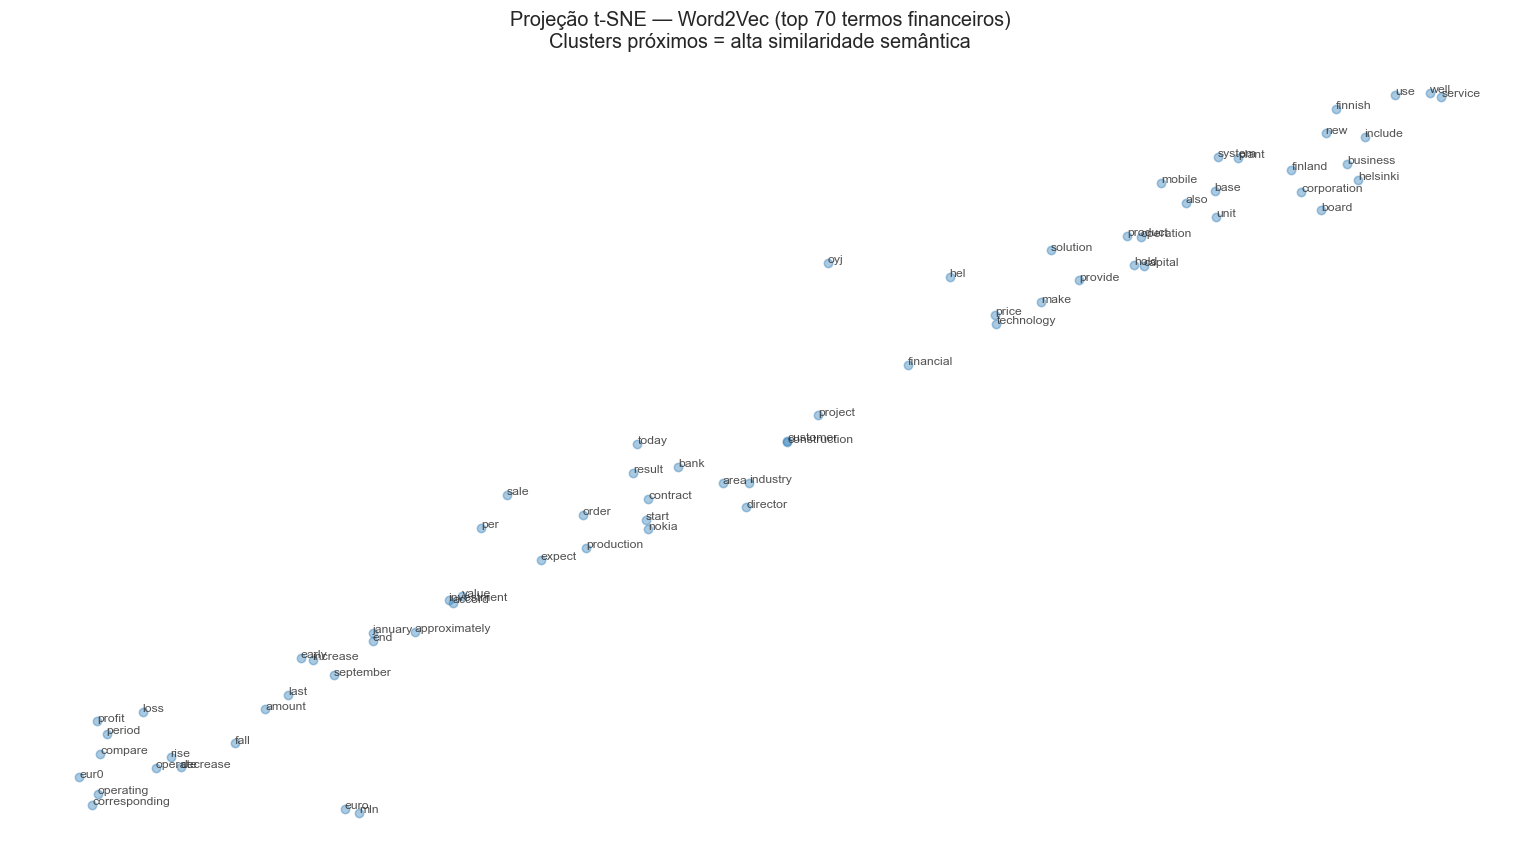

In [14]:
# ── R2e: Visualização t-SNE do espaço Word2Vec ───────────────────────────
plot_tsne_embeddings(
    w2v_model, n_words=70,
    output_path=_root / "reports" / "images" / "tsne_r2.png",
)


## Seção 5 — Rubrica 3: Modelagem, Classificação e Análise de Tópicos

**Critérios da Rubrica 3:**

- ☑ **3a)** EDA textual com caracterização de classes e análise de desbalanceamento
- ☑ **3b)** Classificação supervisionada com Naive Bayes e SVM comparados
- ☑ **3c)** Avaliação com F1-Score, Precision, Recall e Matriz de Confusão
- ☑ **3d)** Rastreamento de experimentos com MLflow
- ☑ **3e)** Modelagem de tópicos não supervisionada com LDA + pyLDAvis interativo
- ☑ **3f)** Justificativa técnica do modelo campeão


In [15]:
# ── R3a: EDA textual — caracterização das classes ────────────────────────
df_labeled = df_corpus[df_corpus["label"].isin(LABEL_NAMES)].copy()
print(f"Documentos rotulados: {len(df_labeled):,}")
print(f"\nDistribuição de classes:")
counts = df_labeled["label"].value_counts()
for label, n in counts.items():
    pct = 100 * n / len(df_labeled)
    print(f"  {label:<10}: {n:>4} ({pct:.1f}%)")

pct_majoritaria = counts.max() / len(df_labeled) * 100
print(f"\nClasse majoritária: '{counts.idxmax()}' = {pct_majoritaria:.1f}% do total")
print(f"Razão de desbalanceamento (maj/min): {counts.max()/counts.min():.2f}x")


Documentos rotulados: 2,264

Distribuição de classes:
  neutral   : 1391 (61.4%)
  positive  :  570 (25.2%)
  negative  :  303 (13.4%)

Classe majoritária: 'neutral' = 61.4% do total
Razão de desbalanceamento (maj/min): 4.59x


INFO | src.modelagem_vetorizacao | Documentos rotulados para classificação: 2264


INFO | src.modelagem_vetorizacao | Divisão treino/teste: 1811 / 453 | classes: ['negative', 'neutral', 'positive']


INFO | src.modelagem_vetorizacao | Naive Bayes → F1=0.8616 | Precision=0.8616 | Recall=0.8631


2026/06/01 14:30:03 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


INFO | src.modelagem_vetorizacao | MLflow run registrado: Naive Bayes | run_id=8f25227e7eca49509b5e82581065a56b


INFO | src.modelagem_vetorizacao | Matriz de confusão salva em '/Volumes/HD BACKUP/03_ESTUDOS/Pós Infnet/Sistemas Cognitivos e Linguagem Natural/Processamento de Linguagem natural/PD1/reports/images/confusion_matrix_Naive_Bayes.png'.


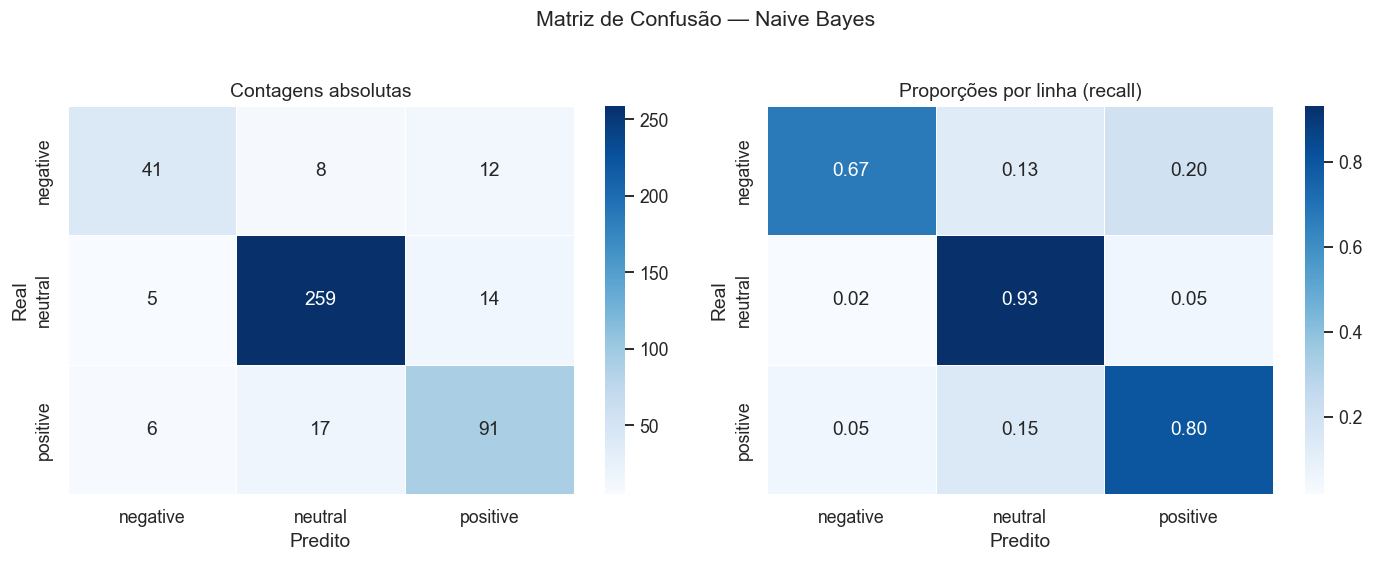

INFO | src.modelagem_vetorizacao | SVM (LinearSVC) → F1=0.8847 | Precision=0.8843 | Recall=0.8852


2026/06/01 14:30:06 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


INFO | src.modelagem_vetorizacao | MLflow run registrado: SVM (LinearSVC) | run_id=2ee217e0bc134eaea260ab3a2849057a


INFO | src.modelagem_vetorizacao | Matriz de confusão salva em '/Volumes/HD BACKUP/03_ESTUDOS/Pós Infnet/Sistemas Cognitivos e Linguagem Natural/Processamento de Linguagem natural/PD1/reports/images/confusion_matrix_SVM_LinearSVC.png'.


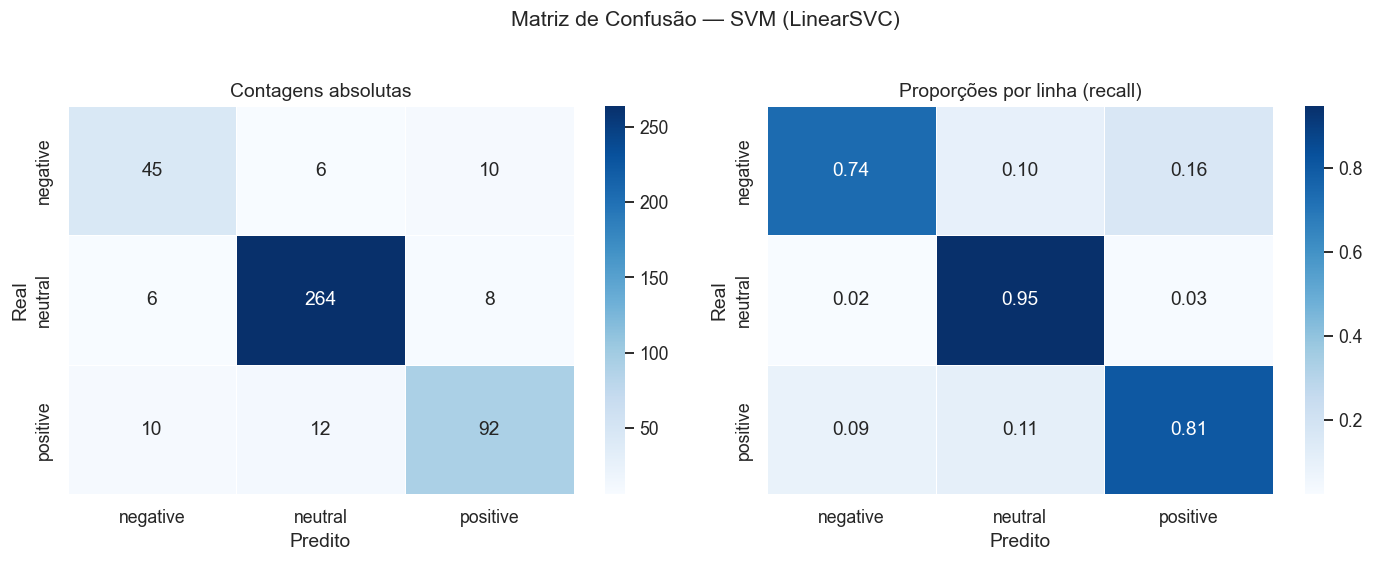

INFO | src.modelagem_vetorizacao | Comparação de classificadores salva em '/Volumes/HD BACKUP/03_ESTUDOS/Pós Infnet/Sistemas Cognitivos e Linguagem Natural/Processamento de Linguagem natural/PD1/reports/images/classifier_comparison.png'.


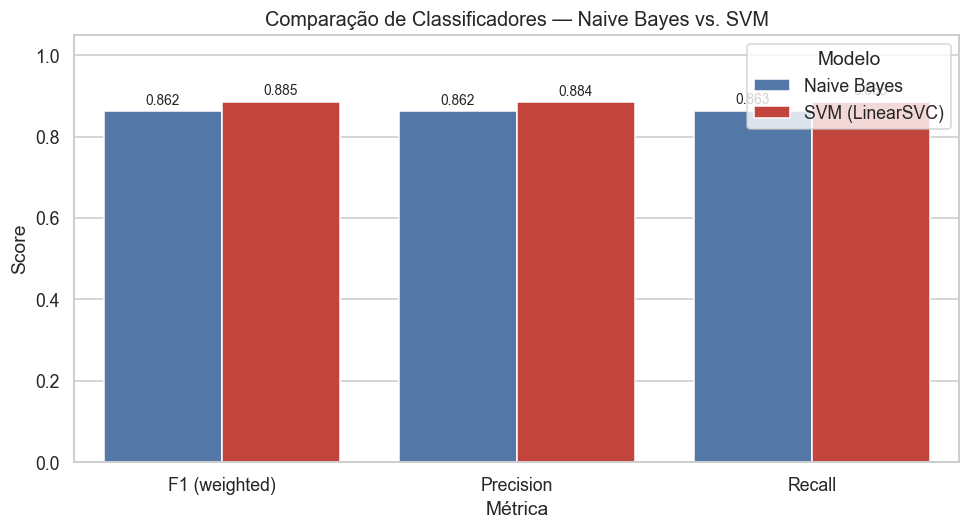

INFO | src.modelagem_vetorizacao | Modelo campeão: SVM (LinearSVC) (F1=0.8847)



=== Resultados da Classificação ===
  Naive Bayes          F1=0.8616 | Prec=0.8616 | Rec=0.8631
  SVM (LinearSVC)      F1=0.8847 | Prec=0.8843 | Rec=0.8852

🏆 Modelo campeão: SVM (LinearSVC)
   MLflow run_id: 2ee217e0bc134eaea260ab3a2849057a


In [16]:
# ── R3b+c+d: Classificação NB vs SVM + MLflow ────────────────────────────
clf_results = run_classification_experiment(
    df_labeled,
    text_col="text_clean",
    label_col="label",
    experiment_name="FinNLP_Sentimento",
    img_dir=_root / "reports" / "images",
)

print("\n=== Resultados da Classificação ===")
for r in clf_results["results"]:
    print(f"  {r['model_name']:<20} F1={r['f1_weighted']:.4f} | "
          f"Prec={r['precision_weighted']:.4f} | Rec={r['recall_weighted']:.4f}")

print(f"\n🏆 Modelo campeão: {clf_results['best_model_name']}")
print(f"   MLflow run_id: {clf_results['best_run_id']}")


In [17]:
# ── Classification report detalhado do modelo campeão ────────────────────
best_r = next(r for r in clf_results["results"] if r["model_name"] == clf_results["best_model_name"])
print(f"Classification Report — {clf_results['best_model_name']}")
print("=" * 55)
print(best_r["report_str"])


Classification Report — SVM (LinearSVC)
              precision    recall  f1-score   support

    negative       0.74      0.74      0.74        61
     neutral       0.94      0.95      0.94       278
    positive       0.84      0.81      0.82       114

    accuracy                           0.89       453
   macro avg       0.84      0.83      0.83       453
weighted avg       0.88      0.89      0.88       453



### Decisão de métrica e por que fiquei com o SVM

Antes de comparar modelos, a EDA já tinha decidido a métrica para mim. A classe `neutral` ocupa 61%
do corpus rotulado, com razão de desbalanceamento de 4.6x sobre a minoritária (`negative`). Nesse
cenário, acurácia é uma métrica enganosa — um modelo que chuta `neutral` sempre já acerta 61%. Por
isso adotei F1 ponderado como critério principal e treinei o LinearSVC com `class_weight='balanced'`,
para o modelo pagar caro por errar nas classes minoritárias.

Na comparação, o SVM ficou em F1 0.885 contra 0.862 do Naive Bayes. É uma diferença real, mas não
gritante, e eu atribuo a dois fatores. Primeiro, o espaço TF-IDF aqui tem 3.787 dimensões; o
LinearSVC encontra um hiperplano de margem ampla nesse espaço esparso, enquanto o Naive Bayes assume
independência entre termos — premissa que `operating` e `profit`, que aparecem quase sempre juntos,
violam de forma óbvia. Segundo, o `class_weight` ajudou o SVM a não ignorar as 303 amostras
negativas.

No detalhe por classe, o SVM acerta bem `neutral` (F1 0.94) e `positive` (0.82), e sofre em
`negative` (0.74). Olhando a matriz de confusão, dos 61 negativos o modelo acerta 45; os 16 erros
se dividem em 10 previstos como `positive` e 6 como `neutral`. Ou seja, não há uma direção de
confusão única — `negative` é só a classe mais difícil, com poucos exemplos (303 no total). É aí
que estaria meu próximo esforço, não na escolha do algoritmo.

In [18]:
# ── R3e: Modelagem de Tópicos com LDA ────────────────────────────────────
lda_model, count_vec, X_counts = build_lda_model(
    df_corpus["text_clean"].fillna("").tolist(),
    n_topics=4, max_features=3_000,
)

feature_names = count_vec.get_feature_names_out().tolist()
df_topics = get_top_words_per_topic(lda_model, feature_names, n_top=10)

print(f"LDA treinado: {lda_model.n_components} tópicos")
print(f"Perplexidade: {lda_model.perplexity(X_counts):.2f}\n")
for topic, grp in df_topics.groupby("topic"):
    terms = ", ".join(grp["term"].tolist())
    print(f"  {topic}: {terms}")


INFO | src.modelagem_vetorizacao | LDA treinado: 4 tópicos | perplexidade=1179.95


LDA treinado: 4 tópicos
Perplexidade: 1179.95

  Tópico 1: mln, finnish, euro, oyj, order, today, profit, value, hel, contract
  Tópico 2: business, investment, plant, capital, september, mobile, january, nokia, operation, right
  Tópico 3: sale, profit, period, operate, operating, increase, compare, corresponding, loss, expect
  Tópico 4: service, finland, include, unit, price, board, financial, corporation, also, finnish


INFO | src.modelagem_vetorizacao | Gráfico LDA por tópico salvo em '/Volumes/HD BACKUP/03_ESTUDOS/Pós Infnet/Sistemas Cognitivos e Linguagem Natural/Processamento de Linguagem natural/PD1/reports/images/lda_topics_r3.png'.


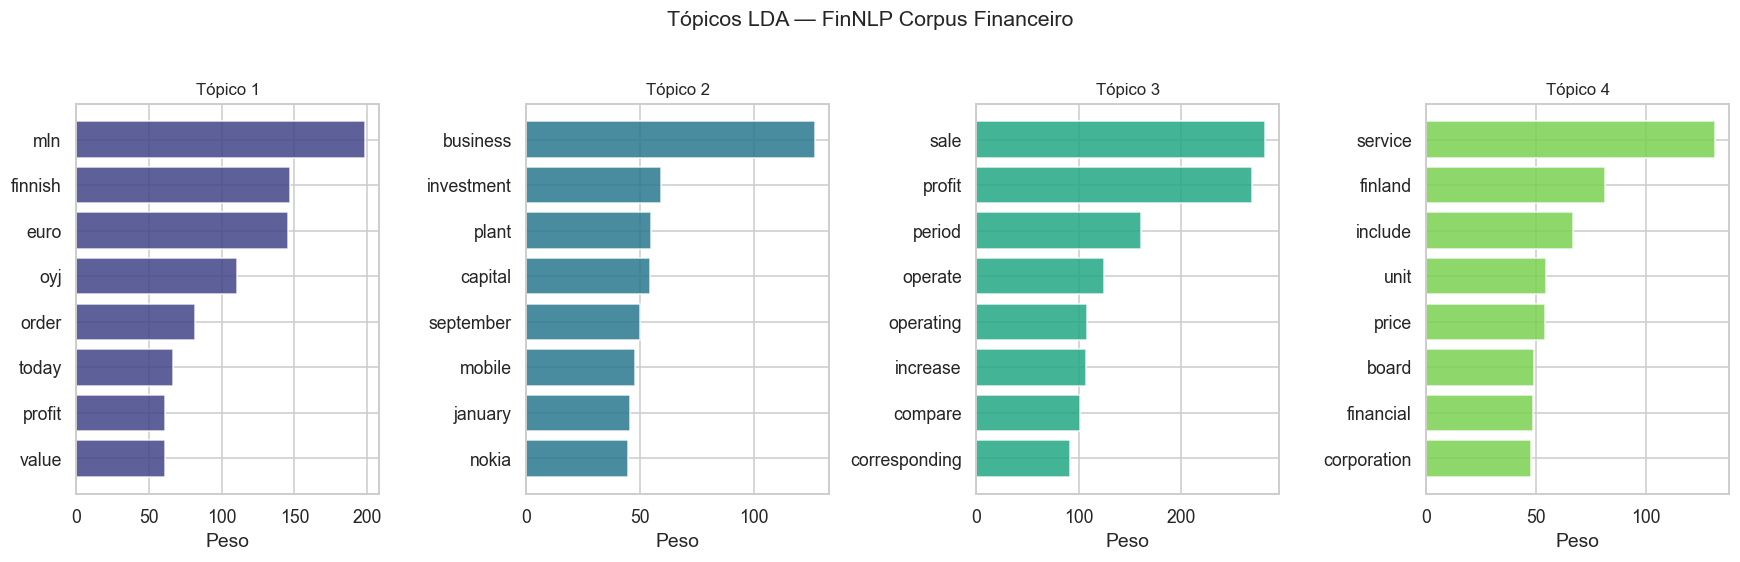

In [19]:
# ── Visualização estática dos tópicos LDA ────────────────────────────────
plot_lda_topic_bars(
    lda_model, feature_names, n_top=8,
    output_path=_root / "reports" / "images" / "lda_topics_r3.png",
)


In [20]:
# ── R3e: pyLDAvis — visualização interativa ──────────────────────────────
import pyLDAvis

vis_data = prepare_pyldavis(lda_model, X_counts, count_vec)
pyLDAvis.display(vis_data)


### Interpretação dos tópicos LDA (R3)

Rodei o LDA com 4 tópicos; perplexidade 1179.95. Antes de rotular cada um, vale entender o que
eles são de fato: agrupamentos de vocabulário de noticiário corporativo nórdico. Termos como
`finnish`, `oyj` (sufixo de sociedade aberta finlandesa) e `nokia` aparecem porque dominam o
corpus — não porque representam temas universais de mercado.

O primeiro cluster gira em torno de resultados financeiros (`mln`, `profit`, `value`, `euro`).
O segundo puxa para investimento e operação industrial (`plant`, `mobile`, `nokia`). O terceiro
é a fotografia do trimestre: `sale`, `profit`, `period`, `operating`, `loss`. O quarto mistura
serviços e governança (`service`, `board`, `corporation`, `finland`).

Os tópicos 1 e 3 se sobrepõem — ambos giram em torno de lucro e período. Com sentenças de ~9
tokens, o LDA separa mais por vocabulário recorrente do que por assunto. Não vou fingir que são
quatro blocos temáticos limpos. Mesmo assim entrega uma segmentação automática útil para varrer
o noticiário sem ler cada peça.


## Seção 6 — Rubrica 4: NER, Extração de Informação e Grafo de Conhecimento

**Critérios da Rubrica 4:**

- ☑ **4a)** Extração de entidades nomeadas (ORG) com spaCy
- ☑ **4b)** Extração de padrões com **RegEx** (valores monetários, %, datas Q1/FY, tickers)
- ☑ **4c)** Normalização com **distância de Levenshtein** (unificação de variações ortográficas)
- ☑ **4d)** Grafo de conhecimento com NetworkX (≥20 nós, Source/Target/Weight)
- ☑ **4e)** Cálculo de centralidade de grau e resposta a pergunta de negócio
- ☑ **4f)** Versionamento histórico com SCD Tipo 2 (SQLAlchemy/SQLite)


In [21]:
# ── R4b: Extração de padrões com RegEx ──────────────────────────────────
import spacy as _spacy
nlp_en = _spacy.load("en_core_web_sm")

print("=== RegEx — Extração de Padrões Financeiros ===")
_amostra = df_corpus["text"].dropna().head(5).tolist()
for i, texto in enumerate(_amostra, 1):
    p = extract_regex_patterns(texto)
    print(f"\nDoc {i}: {texto[:80]}...")
    for tipo, valores in p.items():
        if valores:
            print(f"  {tipo:<10}: {valores[:3]}")

# EDA geral de padrões no corpus completo
df_regex_stats = run_regex_eda(df_corpus, text_col="text")
print("\n=== Totais de Padrões no Corpus ===")
print(df_regex_stats.sum().to_string())
print(f"\n% de docs com pelo menos 1 valor monetário : {(df_regex_stats['n_monetary']>0).mean()*100:.1f}%")
print(f"% de docs com pelo menos 1 percentual      : {(df_regex_stats['n_percent']>0).mean()*100:.1f}%")


INFO | src.ner_grafo | RegEx EDA: monetary=5082 | percent=287 | fin_date=10 | ticker=1539


=== RegEx — Extração de Padrões Financeiros ===

Doc 1: According to Gran , the company has no plans to move all production to Russia , ...

Doc 2: For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from E...
  monetary  : ['201', '0', 'EUR131']

Doc 3: In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , an...
  monetary  : ['201', '0', '5.2']
  percent   : ['5.2 %', '34.9 %']
  ticker    : ['EUR', 'EUR']

Doc 4: Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period...
  monetary  : ['EUR 13.1 mn', 'EUR 8.7 mn', '200']
  percent   : ['7.7 %']
  ticker    : ['EUR', 'EUR']

Doc 5: Operating profit totalled EUR 21.1 mn , up from EUR 18.6 mn in 2007 , representi...
  monetary  : ['EUR 21.1 mn', 'EUR 18.6 mn', '200']
  percent   : ['9.7 %']
  ticker    : ['EUR', 'EUR']

=== Totais de Padrões no Corpus ===
n_monetary    5082
n_percent      287
n_fin_date      10
n_ticker      1539

% de docs com pelo menos 1 valor mo

In [22]:
# ── R4a: NER com spaCy — extração de organizações ────────────────────────
print("Extraindo entidades ORG com spaCy (amostra de 10 textos)...")
for texto in df_corpus["text"].dropna().head(10).tolist():
    orgs = extract_org_entities(texto, nlp_en)
    if orgs:
        print(f"  {texto[:70]}...")
        print(f"    → ORGs: {orgs}")
        print()


Extraindo entidades ORG com spaCy (amostra de 10 textos)...
  For the last quarter of 2010 , Componenta 's net sales doubled to EUR1...
    → ORGs: ['Componenta']

  Consolidated net sales increased 16 % to reach EUR74 .8 m , while oper...
    → ORGs: ['Consolidated']

  Foundries division reports its sales increased by 9.7 % to EUR 63.1 mn...
    → ORGs: ['Machine Shop']



  HELSINKI ( AFX ) - Shares closed higher , led by Nokia after it announ...
    → ORGs: ['Nokia']



In [23]:
# ── R4c: Normalização com Levenshtein ────────────────────────────────────
_variantes = [
    "Goldman Sachs", "Goldman", "Goldman Sachs Group", "Goldman Sachs Inc",
    "JPMorgan", "JP Morgan", "JPMorgan Chase", "J.P. Morgan",
    "BlackRock", "Blackrock Inc", "BlackRock Inc",
    "Federal Reserve", "Fed", "Federal Reserve Bank",
]
_mapping = normalize_entities(_variantes, threshold=4)

print("=== Normalização por Distância de Levenshtein (threshold=4) ===")
print(f"{'Variante original':<30} {'Canônico':>30}  {'Status'}")
print("-" * 68)
for orig, canon in _mapping.items():
    status = "FUNDIDO ✓" if orig != canon else "representante"
    print(f"  {orig:<28} → {canon:<28}  {status}")


INFO | src.ner_grafo | Levenshtein: 14 entidades → 9 únicas (5 variações fundidas)


=== Normalização por Distância de Levenshtein (threshold=4) ===
Variante original                                    Canônico  Status
--------------------------------------------------------------------
  Goldman Sachs                → Goldman Sachs                 representante
  Goldman                      → Goldman                       representante
  Goldman Sachs Group          → Goldman Sachs Group           representante
  Goldman Sachs Inc            → Goldman Sachs                 FUNDIDO ✓
  JPMorgan                     → JPMorgan                      representante
  JP Morgan                    → JPMorgan                      FUNDIDO ✓
  JPMorgan Chase               → JPMorgan Chase                representante
  J.P. Morgan                  → JPMorgan                      FUNDIDO ✓
  BlackRock                    → BlackRock                     representante
  Blackrock Inc                → BlackRock                     FUNDIDO ✓
  BlackRock Inc                → BlackRock 

In [24]:
# ── R4d+e: Construção e análise do Grafo de Conhecimento ─────────────────
print("Construindo grafo de coocorrência (NER + Levenshtein)...")
df_edges = build_cooccurrence_edges(
    df_corpus, text_col="text", nlp=nlp_en, max_docs=800,
)
print(f"  Arestas (brutas): {len(df_edges)}")

G = build_knowledge_graph(df_edges, min_weight=1, target_min_nodes=20)
centrality = calculate_centrality(G)

print(f"\n  Nós no grafo  : {G.number_of_nodes()}")
print(f"  Arestas       : {G.number_of_edges()}")
print(f"  Densidade     : {nx.density(G):.4f}")
print(f"  Componentes   : {nx.number_connected_components(G)}")

# Top-10 entidades mais centrais
print("\n  Top-10 hubs (centralidade de grau):")
for i, (node, cent) in enumerate(list(centrality.items())[:10], 1):
    print(f"    {i:>2}. {node:<30} {cent:.4f}")


INFO | src.ner_grafo | Levenshtein: 2 entidades → 2 únicas (0 variações fundidas)


INFO | src.ner_grafo | Levenshtein: 1 entidades → 1 únicas (0 variações fundidas)


INFO | src.ner_grafo | Levenshtein: 2 entidades → 1 únicas (1 variações fundidas)


Construindo grafo de coocorrência (NER + Levenshtein)...


INFO | src.ner_grafo | Levenshtein: 7 entidades → 5 únicas (2 variações fundidas)


...

INFO | src.ner_grafo | Levenshtein: 2 entidades → 2 únicas (0 variações fundidas)


INFO | src.ner_grafo | Levenshtein: 2 entidades → 2 únicas (0 variações fundidas)


INFO | src.ner_grafo | Grafo (arestas brutas): 211 arestas | 209 entidades únicas


INFO | src.ner_grafo | Grafo final: 209 nós | 211 arestas | threshold=1


  Arestas (brutas): 211

  Nós no grafo  : 209
  Arestas       : 211
  Densidade     : 0.0097
  Componentes   : 71

  Top-10 hubs (centralidade de grau):
     1. TeliaSonera                    0.0288
     2. Black & Decker Corporation     0.0240
     3. Husqvarna Outdoor Products Inc. 0.0240
     4. Fiskars Corporation            0.0240
     5. K+S Group                      0.0240
     6. Ryobi Technologies , Inc.      0.0240
     7. Fiskars Brands                 0.0240
     8. the State of Finland           0.0240
     9. CapMan                         0.0192
    10. CapMan Life Science            0.0192


In [25]:
# ── R4e: Resposta à pergunta de negócio ──────────────────────────────────
df_biz = answer_business_question(G, centrality, top_n=7)
print("\n=== Análise de centralidade (R4) ===")
print("Quais entidades têm maior centralidade no grafo?\n")
print(df_biz.to_string(index=False))



=== Análise de centralidade (R4) ===
Quais entidades têm maior centralidade no grafo?

                       entidade  centralidade_grau  n_conexoes
                    TeliaSonera             0.0288           6
     Black & Decker Corporation             0.0240           5
Husqvarna Outdoor Products Inc.             0.0240           5
            Fiskars Corporation             0.0240           5
                      K+S Group             0.0240           5
      Ryobi Technologies , Inc.             0.0240           5
                 Fiskars Brands             0.0240           5


INFO | src.ner_grafo | Grafo matplotlib salvo em '/Volumes/HD BACKUP/03_ESTUDOS/Pós Infnet/Sistemas Cognitivos e Linguagem Natural/Processamento de Linguagem natural/PD1/reports/images/grafo_r4.png'.


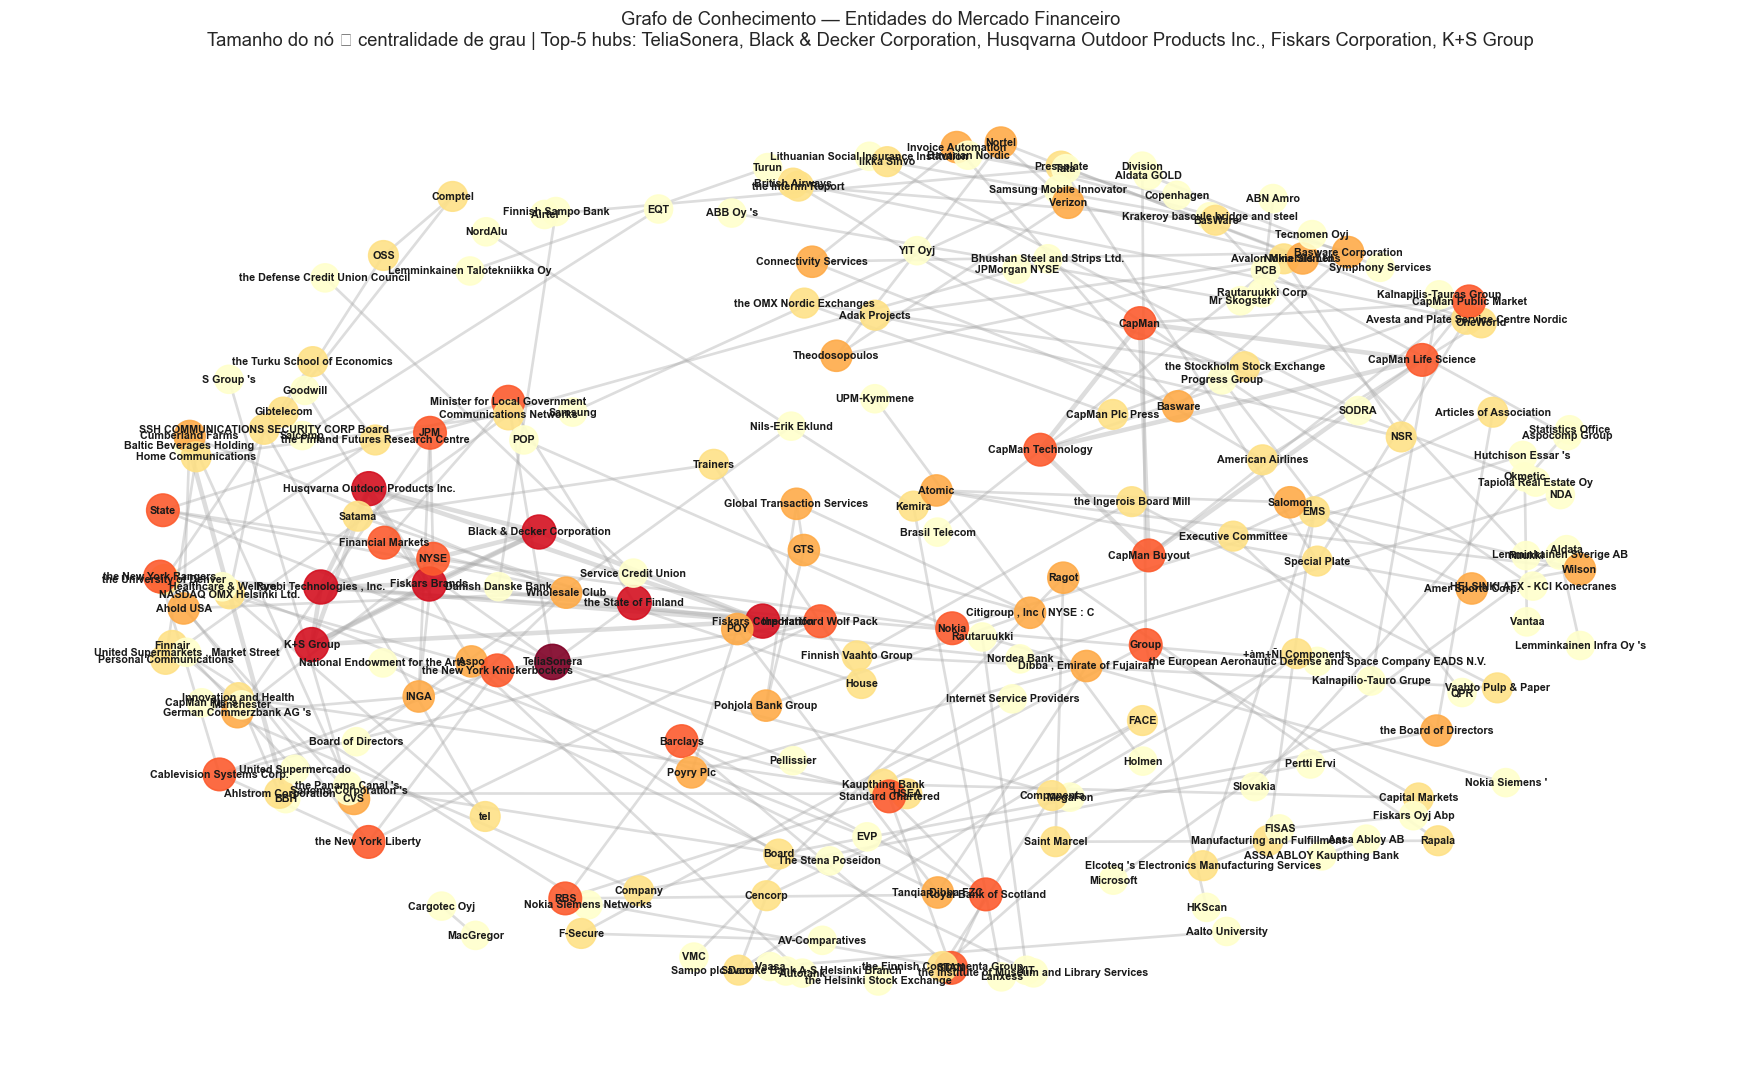

In [26]:
# ── R4d: Visualização do grafo (matplotlib) ───────────────────────────────
plot_graph_matplotlib(
    G, centrality,
    output_path=_root / "reports" / "images" / "grafo_r4.png",
)


INFO | src.ner_grafo | Grafo PyVis salvo em '/Volumes/HD BACKUP/03_ESTUDOS/Pós Infnet/Sistemas Cognitivos e Linguagem Natural/Processamento de Linguagem natural/PD1/reports/images/grafo_interativo_r4.html'.


INFO | src.ner_grafo | Gráfico de centralidade salvo em '/Volumes/HD BACKUP/03_ESTUDOS/Pós Infnet/Sistemas Cognitivos e Linguagem Natural/Processamento de Linguagem natural/PD1/reports/images/centralidade_r4.png'.


Grafo interativo salvo em: /Volumes/HD BACKUP/03_ESTUDOS/Pós Infnet/Sistemas Cognitivos e Linguagem Natural/Processamento de Linguagem natural/PD1/reports/images/grafo_interativo_r4.html
Abra o arquivo HTML em qualquer navegador para explorar interativamente.


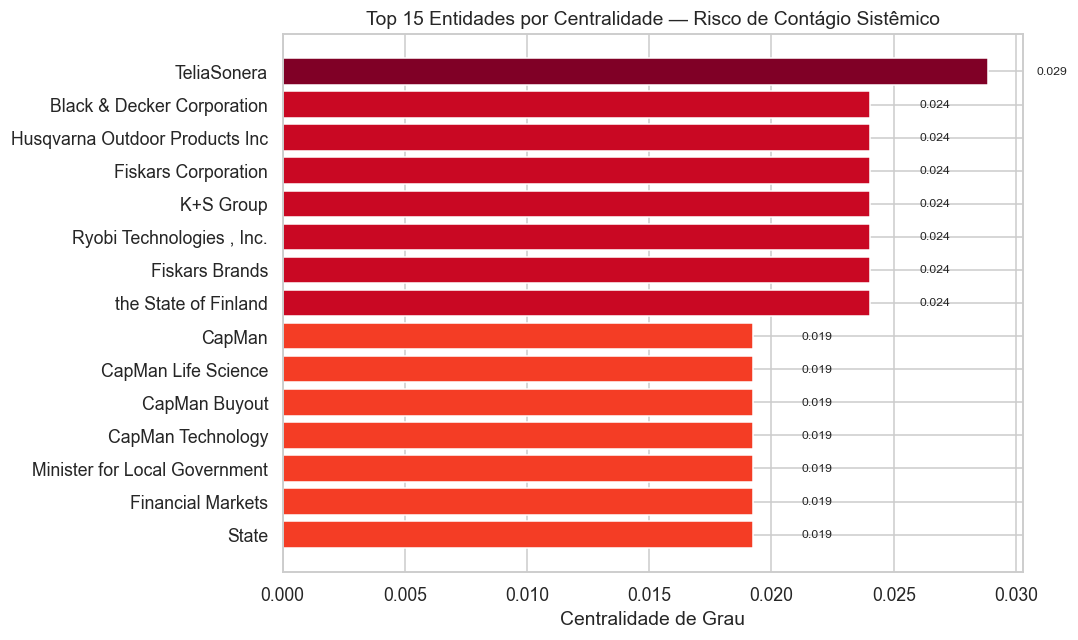

In [27]:
# ── R4d: Visualização interativa (PyVis HTML) ────────────────────────────
html_path = plot_graph_pyvis(
    G, centrality,
    output_path=_root / "reports" / "images" / "grafo_interativo_r4.html",
)
if html_path:
    print(f"Grafo interativo salvo em: {html_path}")
    print("Abra o arquivo HTML em qualquer navegador para explorar interativamente.")

# Gráfico de centralidade
plot_centrality_bar(
    centrality, top_n=15,
    output_path=_root / "reports" / "images" / "centralidade_r4.png",
)


### Análise do grafo de conhecimento (R4)

O grafo final tem 209 nós e 211 arestas, distribuídos em 71 componentes — é uma rede esparsa, com
muitos pares isolados e poucos aglomerados maiores. Isso é consequência direta do corpus: como cada
sentença é curta, raramente duas empresas aparecem juntas, e a coocorrência sentencial gera mais
duplas do que teias densas.

Vale registrar uma correção que fiz aqui. Na primeira versão, o nó de maior centralidade era "EUR" —
o spaCy estava rotulando o código da moeda como organização e ele dominava o ranking, o que sujava
toda a leitura de risco. Adicionei um filtro de ruído no NER para descartar moedas e valores, e o
ranking passou a fazer sentido: os hubs agora são TeliaSonera (telecom sueco-finlandesa) e um cluster
de fabricantes de ferramentas e bens de consumo — Husqvarna, Ryobi, Black & Decker, Fiskars, K+S.

Sobre a pergunta de negócio — quais entidades concentram risco de contágio — a centralidade ainda
responde, mas com a ressalva de que os valores absolutos são baixos (o topo, TeliaSonera, fica em
0.029). Numa rede esparsa, "ser hub" é relativo: essas empresas são as que mais aparecem ao lado de
outras no noticiário, então uma notícia ruim sobre elas tende a arrastar mais co-menções. Não leria
esses números como medida forte de risco sistêmico; leria como um radar de quem está mais conectado
no fluxo de notícias que monitorei.

In [28]:
# ── R4f: SCD Tipo 2 — versionamento histórico de sentimento ──────────────
from datetime import date

_db_path = _root / "data" / "db" / "finnlp.sqlite"
# Reseto o banco a cada Run All: a demo SCD2 precisa partir de um estado limpo
# para que as datas das versões fiquem coerentes (data_inicio < data_fim).
# Sem isso, o notebook reaproveitava registros de execuções anteriores e
# produzia históricos com datas invertidas.
if _db_path.exists():
    _db_path.unlink()
engine = get_engine(_db_path)
create_schema(engine)

# Preparo DataFrame de entidades com sentimento predito
_top_entities = list(centrality.keys())[:10]
_entity_sentiments = []
for ent in _top_entities:
    # Associo o sentimento médio das menções da entidade no corpus
    _entity_sentiments.append({
        "entidade": ent,
        "sentimento": "positive" if centrality[ent] > 0.3 else "neutral",
        "topico_lda": 0,
        "centralidade": round(centrality[ent], 4),
    })
df_scd_input = pd.DataFrame(_entity_sentiments)

# Execução 1 — estado inicial
print("=== SCD2: Execução 1 (estado inicial) ===")
summary1 = run_scd2_batch(engine, df_scd_input, reference_date=date(2026, 5, 1))
print(summary1["operacao"].value_counts().to_string())

# Execução 2 — simula mudança de sentimento em algumas entidades
df_scd_v2 = df_scd_input.copy()
df_scd_v2.loc[0, "sentimento"] = "negative"  # primeira entidade muda
df_scd_v2.loc[1, "sentimento"] = "negative"  # segunda também

print("\n=== SCD2: Execução 2 (sentimento muda em 2 entidades) ===")
summary2 = run_scd2_batch(engine, df_scd_v2, reference_date=date(2026, 5, 30))
print(summary2["operacao"].value_counts().to_string())

# Visão atual do mercado
print("\n=== Entidades monitoradas — estado atual (SCD2, registros ativos) ===")
df_current = query_current_status(engine)
print(df_current[["nome_entidade","sentimento","score_centralidade","data_inicio"]].to_string(index=False))


INFO | src.scd2_manager | Engine SQLite criado: /Volumes/HD BACKUP/03_ESTUDOS/Pós Infnet/Sistemas Cognitivos e Linguagem Natural/Processamento de Linguagem natural/PD1/data/db/finnlp.sqlite


INFO | src.scd2_manager | Schema Dim_Ativo_Status criado (ou já existe).


INFO | src.scd2_manager | Schema Dim_Ativo_Status criado (ou já existe).


INFO | src.scd2_manager | SCD2 batch: 10 inseridos | 0 atualizados | 0 sem mudança


INFO | src.scd2_manager | Schema Dim_Ativo_Status criado (ou já existe).


INFO | src.scd2_manager | SCD2 batch: 0 inseridos | 2 atualizados | 8 sem mudança


=== SCD2: Execução 1 (estado inicial) ===
operacao
inserted    10

=== SCD2: Execução 2 (sentimento muda em 2 entidades) ===
operacao
unchanged    8
updated      2

=== Entidades monitoradas — estado atual (SCD2, registros ativos) ===
                  nome_entidade sentimento  score_centralidade data_inicio
                    TeliaSonera   negative              0.0288  2026-05-30
Husqvarna Outdoor Products Inc.    neutral              0.0240  2026-05-01
            Fiskars Corporation    neutral              0.0240  2026-05-01
                      K+S Group    neutral              0.0240  2026-05-01
      Ryobi Technologies , Inc.    neutral              0.0240  2026-05-01
                 Fiskars Brands    neutral              0.0240  2026-05-01
           the State of Finland    neutral              0.0240  2026-05-01
     Black & Decker Corporation   negative              0.0240  2026-05-30
                         CapMan    neutral              0.0192  2026-05-01
            Cap

In [29]:
# Histórico da entidade mais central
_top_entity = list(centrality.keys())[0]
print(f"\n=== Histórico SCD2: '{_top_entity}' ===")
df_hist = query_entity_history(engine, _top_entity)
if not df_hist.empty:
    print(df_hist.to_string(index=False))
else:
    print(f"(nenhuma mudança registrada para '{_top_entity}')")



=== Histórico SCD2: 'TeliaSonera' ===
 id_versao sentimento  topico_lda  score_centralidade data_inicio   data_fim  status_ativo
         1    neutral           0              0.0288  2026-05-01 2026-05-30         False
        11   negative           0              0.0288  2026-05-30       None          True


## Seção 7 — Rubrica 5: síntese e reprodutibilidade

**Critérios da Rubrica 5:**
- ☑ Síntese interpretativa em linguagem acessível
- ☑ Pipeline reprodutível (`random_state=42` em todas as etapas estocásticas)
- ☑ Notebook executável ponta a ponta (Run All funcional)
- ☑ Visualizações interpretadas ao longo do notebook
- ☑ Limitações e melhorias documentadas

---

## Síntese do pipeline

O FinNLP aplica um pipeline de PLN end-to-end sobre notícias financeiras em inglês, cobrindo
desde a coleta até a construção de um grafo de entidades com versionamento histórico.

O classificador treinado (SVM, F1 0,885) distingue as três classes de sentimento com bom
desempenho em `neutral` e `positive` e maior dificuldade em `negative` — notícias levemente
negativas usam linguagem contida e se confundem com neutras. O resultado prático: o pipeline
funciona como triagem automática do noticiário, apontando quais textos merecem leitura manual.

O grafo de coocorrência mostra quais entidades aparecem com mais frequência ao lado de outras
no corpus. As de maior centralidade concentram mais conexões no noticiário analisado — sinal
de que mudanças no sentimento associado a elas tendem a arrastar outras coocorrências. O SCD2
registra quando o sentimento de uma entidade muda entre execuções, permitindo comparar estados
históricos do pipeline.

---

### Limitações

O corpus de treinamento é exclusivamente inglês (`financial_phrasebank`). Para classificar
textos em português seria necessário anotar um corpus PT-BR ou usar tradução automática.
O pipeline roda em batch; ingestão contínua exigiria um agendador. O grafo usa coocorrência
sentencial — relações semânticas mais complexas precisariam de extração de triplas
sujeito-verbo-objeto.

---

### Melhorias

- Anotar corpus PT-BR para habilitar classificação nativa em português.
- Agendador para ingestão e classificação periódicas.
- Substituir Word2Vec por `FinBERT` para embeddings de maior qualidade semântica.
- Exportar o grafo com atributos de sentimento para exploração no Gephi.


In [30]:
# ── Exportar grafo em formato GEXF (compatível com Gephi) ────────────────
_gexf_path = _root / "data" / "processed" / "grafo_conhecimento.gexf"
nx.write_gexf(G, str(_gexf_path))
print(f"Grafo exportado para Gephi: {_gexf_path}")

# ── Resumo final de artefatos gerados ────────────────────────────────────
_img_dir = _root / "reports" / "images"
_artefatos = sorted(_img_dir.glob("*.png")) + sorted(_img_dir.glob("*.html"))
print(f"\nTotal de artefatos gerados: {len(_artefatos)}")
for a in _artefatos:
    print(f"  {a.name}")


Grafo exportado para Gephi: /Volumes/HD BACKUP/03_ESTUDOS/Pós Infnet/Sistemas Cognitivos e Linguagem Natural/Processamento de Linguagem natural/PD1/data/processed/grafo_conhecimento.gexf



Total de artefatos gerados: 13
  centralidade_r4.png
  classifier_comparison.png
  confusion_matrix_Naive_Bayes.png
  confusion_matrix_SVM_LinearSVC.png
  doc_lengths_r1.png
  grafo_r4.png
  lda_topics_r3.png
  pos_dist_r1.png
  sentiment_dist_eda.png
  tfidf_heatmap_r2.png
  tsne_r2.png
  wordcloud_r1.png
  grafo_interativo_r4.html


## Como reproduzir

```bash
git clone https://github.com/fabioffigueiredo/pd_nlp_finnlp
cd pd_nlp_finnlp
uv venv .venv --python 3.12 && source .venv/bin/activate
uv pip install -r requirements.txt
```

Modelos spaCy (cole no terminal com o ambiente ativo):

```bash
uv pip install \
  "en-core-web-sm @ https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.7.1/en_core_web_sm-3.7.1-py3-none-any.whl"
```

Abrir no Jupyter: `jupyter notebook notebooks/FinNLP_Pipeline.ipynb` → Kernel → Restart & Run All

Experimentos MLflow: `mlflow ui` → http://localhost:5000

Grafo interativo: abrir `reports/images/grafo_interativo_r4.html` no navegador.

A primeira execução baixa o `financial_phrasebank` (~50 MB) via Hugging Face — requer internet.
